# Building a coronagraph

A coronagraph suppresses the light of an on-axis star while passing an
off-axis planet, and in physicaloptix it is just a longer
{class}`~physicaloptix.OpticalPath`. This notebook shows the problem a
coronagraph solves, walks the light through each stage of a vortex coronagraph,
reveals a buried planet, and wraps the whole thing as a reusable
{class}`~physicaloptix.PathCoronagraph` whose inner working angle and throughput
are measured from the propagated PSFs, never declared.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from physicaloptix import (
    Field,
    Fraunhofer,
    Grid,
    MultiScaleVortex,
    OpticalPath,
    PathCoronagraph,
    PlaneKind,
    Stage,
)
from physicaloptix.elements import SampledOptic

WL, DIAM = 500.0, 6.0
NPUP, NFOC, PSCALE = 96, 200, 0.15
pupil = Grid.pupil(NPUP)
focal = Grid.focal(NFOC, PSCALE)
u = np.asarray(pupil.coords)
ug, vg = np.meshgrid(u, u)
aperture = (np.hypot(ug, vg) <= 0.5).astype(complex)
flat = Field(data=jnp.asarray(aperture), grid=pupil, plane=PlaneKind.PUPIL)
ext = [-focal.extent, focal.extent] * 2


def tilt_field(sep_lod):
    """An off-axis point source: a pupil tilt that lands the PSF at sep_lod."""
    return Field(
        data=jnp.asarray(aperture * np.exp(1j * 2 * np.pi * sep_lod * ug)),
        grid=pupil,
        plane=PlaneKind.PUPIL,
    )


tele = OpticalPath(stages=(Stage("sci", Fraunhofer(grid_in=pupil, grid_out=focal)),))
star_peak = float(np.max(np.abs(np.asarray(tele.propagate(flat)[0].data)) ** 2))

/Users/cspohn/Documents/hwo-dev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The problem

A planet is fainter than its star by a contrast $c$ (an Earth twin is near
$c \sim 10^{-10}$). Through a bare telescope the planet lands on the star's
diffraction halo, and the halo wins: the point below is a companion at
$c = 10^{-4}$, six $\lambda/D$ out, and it is lost in the Airy rings. The radial
cut shows it sitting below the stellar envelope.

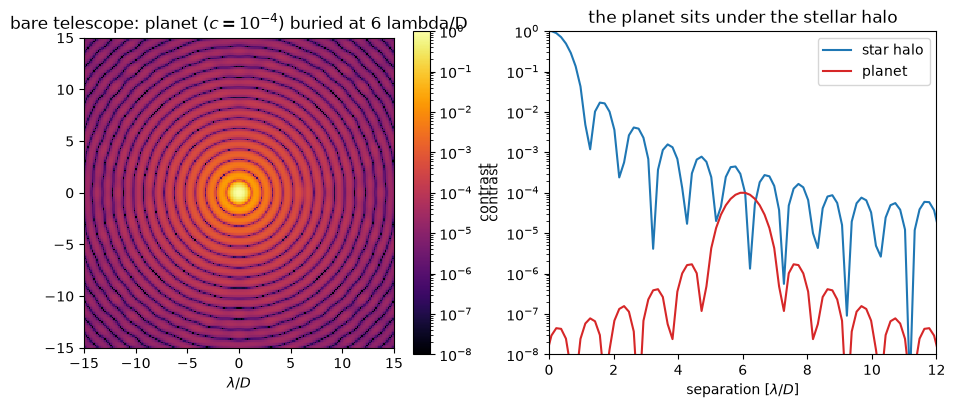

In [2]:
contrast, sep = 1e-4, 6.0
star = np.abs(np.asarray(tele.propagate(flat)[0].data)) ** 2 / star_peak
planet = np.abs(np.asarray(tele.propagate(tilt_field(sep))[0].data)) ** 2 / star_peak
scene = star + contrast * planet

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
im = axes[0].imshow(
    scene,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-8, 1),
    extent=ext,
    interpolation="none",
)
axes[0].set_title(
    f"bare telescope: planet ($c=10^{{-4}}$) buried at {sep:.0f} lambda/D"
)
axes[0].set_xlabel(r"$\lambda/D$"), fig.colorbar(im, ax=axes[0], label="contrast")

row = NFOC // 2
fx = np.asarray(focal.coords)
axes[1].semilogy(fx, star[row, :], color="C0", label="star halo")
axes[1].semilogy(fx, (contrast * planet)[row, :], color="C3", label="planet")
axes[1].set_xlim(0, 12), axes[1].set_ylim(1e-8, 1)
axes[1].set_xlabel(r"separation [$\lambda/D$]"), axes[1].set_ylabel("contrast")
axes[1].set_title("the planet sits under the stellar halo"), axes[1].legend()
plt.show()

## The stages, one at a time

A vortex coronagraph is three stages: a charge-2 {class}`~physicaloptix.MultiScaleVortex` focal-plane mask (the charge is the number of times the mask phase winds by $2\pi$ around its center), a
{class}`~physicaloptix.SampledOptic` Lyot stop, and a final
{class}`~physicaloptix.Fraunhofer` to the science plane. Propagating with
`taps` returns the field just after each named stage, so the mechanism is
visible: the vortex flings the on-axis starlight into a ring outside the
geometric pupil, and the Lyot stop blocks it, leaving almost nothing to reach the focal plane. A vortex mask sits at a focal plane, so this stage internally re-images the pupil (pupil to focal mask and back to a re-imaged pupil); the [architecture page](../explanation/architecture) draws the full four-plane relay, and the `q`, `scaling_factor`, and `window_size` arguments are numerical knobs for the mask grid, not physics.

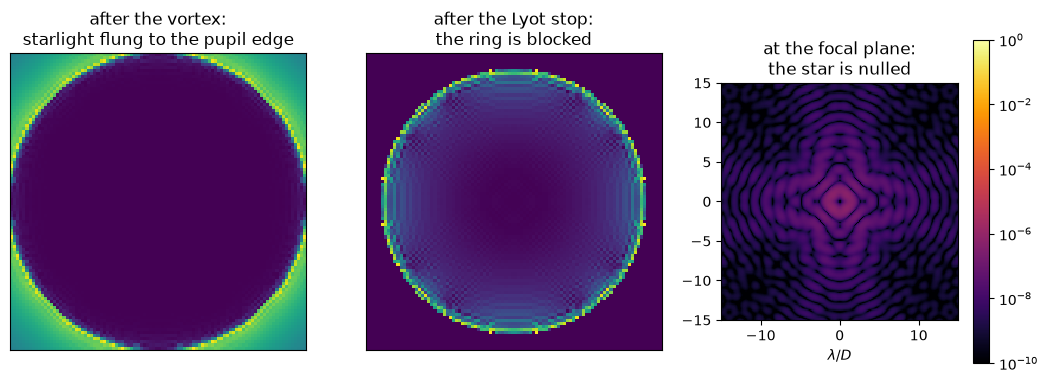

In [3]:
lyot_mask = ((ug**2 + vg**2) <= 0.45**2).astype(float)
vortex = MultiScaleVortex.build(
    charge=2, npup=NPUP, q=64, scaling_factor=4, window_size=16
)
lyot = SampledOptic(
    transmission=jnp.asarray(lyot_mask), grid=pupil, plane=PlaneKind.PUPIL
)
train = OpticalPath(
    stages=(
        Stage("vortex", vortex),
        Stage("lyot", lyot),
        Stage("sci", Fraunhofer(grid_in=pupil, grid_out=focal)),
    )
)

final, taps = train.propagate(flat, taps=("vortex", "lyot"))
post_vortex = np.abs(np.asarray(taps["vortex"].data))
post_lyot = np.abs(np.asarray(taps["lyot"].data))
focal_img = np.abs(np.asarray(final.data)) ** 2 / star_peak

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(post_vortex, origin="lower", cmap="viridis")
axes[0].set_title("after the vortex:\nstarlight flung to the pupil edge")
axes[1].imshow(post_lyot, origin="lower", cmap="viridis")
axes[1].set_title("after the Lyot stop:\nthe ring is blocked")
for ax in axes[:2]:
    ax.set_xticks([]), ax.set_yticks([])
im = axes[2].imshow(
    focal_img,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-10, 1),
    extent=ext,
    interpolation="none",
)
axes[2].set_title("at the focal plane:\nthe star is nulled")
axes[2].set_xlabel(r"$\lambda/D$"), fig.colorbar(im, ax=axes[2])
plt.show()

## The planet, revealed

The vortex nulls the perfect on-axis PSF but leaves an off-axis source almost
untouched: a tilted wavefront misses the mask's central singularity. Sending the
same star and planet through the coronagraph suppresses the halo the planet was
buried under, and the companion emerges above the residual floor.

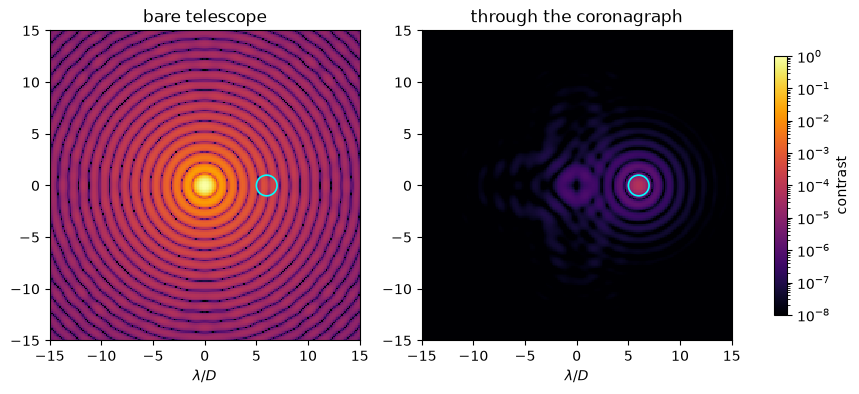

In [4]:
star_c = np.abs(np.asarray(train.propagate(flat)[0].data)) ** 2 / star_peak
planet_c = np.abs(np.asarray(train.propagate(tilt_field(sep))[0].data)) ** 2 / star_peak
revealed = star_c + contrast * planet_c

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, img, title in (
    (axes[0], scene, "bare telescope"),
    (axes[1], revealed, "through the coronagraph"),
):
    im = ax.imshow(
        img,
        origin="lower",
        cmap="inferno",
        norm=LogNorm(1e-8, 1),
        extent=ext,
        interpolation="none",
    )
    ax.set_title(title), ax.set_xlabel(r"$\lambda/D$")
    circ = plt.Circle((sep, 0), 1.0, fill=False, color="cyan", lw=1.2)
    ax.add_patch(circ)
fig.colorbar(im, ax=axes, label="contrast", shrink=0.8)
plt.show()

## The inner working angle is a tradeoff

Suppressing the star costs planet light near the axis. The **throughput**
$T(\theta)$ is the fraction of a point source's light that survives the
coronagraph, and it rises from zero through the **inner working angle** (IWA),
the separation where $T$ reaches half its far-field value. Below the IWA the
off-axis PSF is itself suppressed; above it, the planet passes. Both come from propagating off-axis sources, not from a specification. The outer working angle (OWA) is the complementary bound: the largest separation the coronagraph is designed to serve.

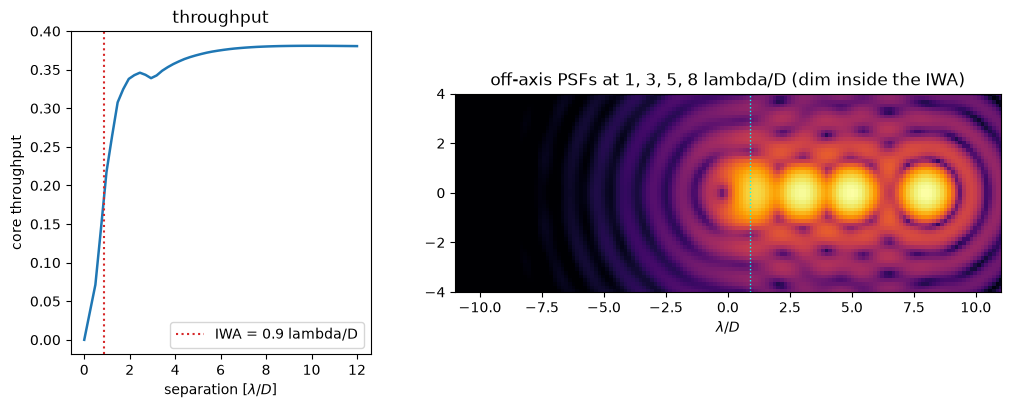

In [5]:
core_path = OpticalPath(
    stages=(Stage("vortex", vortex), Stage("lyot", lyot))
)  # ends in PUPIL
coro = PathCoronagraph.from_path(
    core_path, flat, diameter_m=DIAM, owa_lod=16.0, wavelength_nm=WL
)

seps = np.linspace(0.0, 12.0, 50)
thr = np.array([float(coro.throughput(s, WL)) for s in seps])

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.1, 2]}
)
axes[0].plot(seps, thr, color="C0", lw=1.8)
axes[0].axvline(
    float(coro.IWA), color="C3", ls=":", label=f"IWA = {coro.IWA:.1f} lambda/D"
)
axes[0].set_xlabel(r"separation [$\lambda/D$]"), axes[0].set_ylabel("core throughput")
axes[0].set_title("throughput"), axes[0].legend()

gallery = np.zeros((NFOC, NFOC))
for s in (1.0, 3.0, 5.0, 8.0):
    gallery += np.abs(np.asarray(train.propagate(tilt_field(s))[0].data)) ** 2
im = axes[1].imshow(
    gallery / gallery.max(),
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-4, 1),
    extent=ext,
    interpolation="none",
)
axes[1].axvline(float(coro.IWA), color="cyan", ls=":", lw=1)
axes[1].set_xlim(-11, 11), axes[1].set_ylim(-4, 4)
axes[1].set_title("off-axis PSFs at 1, 3, 5, 8 lambda/D (dim inside the IWA)")
axes[1].set_xlabel(r"$\lambda/D$")
plt.show()

## A design knob: vortex charge

The vortex charge sets the trade between suppression and inner working angle. A
higher, even charge nulls a more forgiving on-axis field (better against a
finite stellar size and low-order aberration) but pushes the throughput curve
outward, costing access to close-in planets. Charge 2 and charge 4 make the
tradeoff concrete.

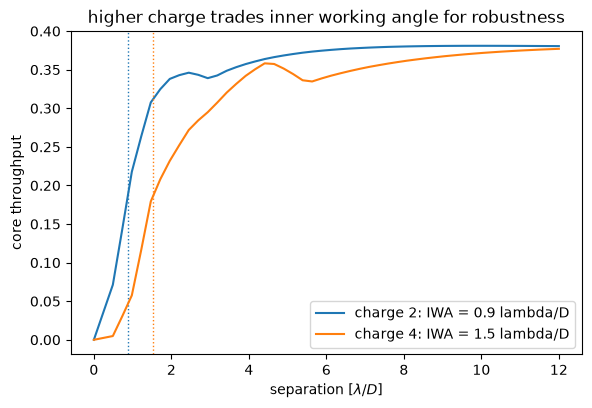

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for charge, color in ((2, "C0"), (4, "C1")):
    vx = MultiScaleVortex.build(
        charge=charge, npup=NPUP, q=64, scaling_factor=4, window_size=16
    )
    cp = OpticalPath(stages=(Stage("vortex", vx), Stage("lyot", lyot)))
    cor = PathCoronagraph.from_path(
        cp, flat, diameter_m=DIAM, owa_lod=16.0, wavelength_nm=WL
    )
    t = np.array([float(cor.throughput(s, WL)) for s in seps])
    ax.plot(
        seps, t, color=color, label=f"charge {charge}: IWA = {cor.IWA:.1f} lambda/D"
    )
    ax.axvline(float(cor.IWA), color=color, ls=":", lw=1)
ax.set_xlabel(r"separation [$\lambda/D$]"), ax.set_ylabel("core throughput")
ax.set_title("higher charge trades inner working angle for robustness")
ax.legend()
plt.show()

## The reusable object

`PathCoronagraph` presents the `AbstractCoronagraph` interface the rest of the
simulation suite consumes: an on-axis PSF, a throughput curve, an inner working
angle. A downstream image simulator or exposure-time calculator takes this
object and never touches the propagation inside it, so a live-propagation
coronagraph and a precomputed sampled-table one are interchangeable.

IWA = 0.89 lambda/D,  OWA = 16.0 lambda/D
throughput at 3 lambda/D = 0.338


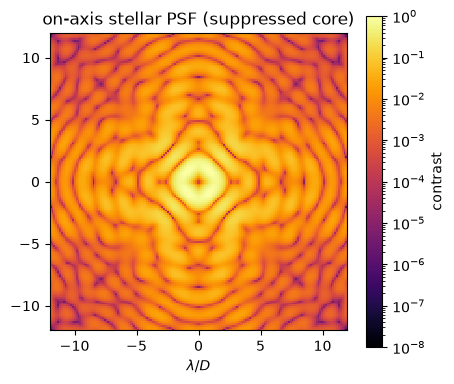

In [7]:
lod_rad = WL * 1e-9 / DIAM
star_psf = np.asarray(coro.on_axis_psf(WL, 0.15 * lod_rad, 160))
print(f"IWA = {coro.IWA:.2f} lambda/D,  OWA = {coro.OWA:.1f} lambda/D")
print(f"throughput at 3 lambda/D = {float(coro.throughput(3.0, WL)):.3f}")

fig, ax = plt.subplots(figsize=(4.8, 4.3))
half = 160 / 2 * 0.15
im = ax.imshow(
    star_psf / star_psf.max(),
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-8, 1),
    extent=[-half, half] * 2,
    interpolation="none",
)
ax.set_title("on-axis stellar PSF (suppressed core)")
ax.set_xlabel(r"$\lambda/D$"), fig.colorbar(im, ax=ax, label="contrast")
plt.show()

## Where to go next

- Real coronagraphs face wavefront error, which sets the deep contrast floor.
  **[Wavefront error and elements](04_Wavefront_Error_and_Elements)** shows how
  aberrations enter a path.
- **[Speckles from first principles](05_Speckles_from_First_Principles)** builds
  the theory of the residual starlight a coronagraph cannot remove.
- The [architecture page](../explanation/architecture) explains the
  `AbstractCoronagraph` slot and how a sampled table fills it interchangeably.